In [3]:
# Run this in its own cell *before* the training script below.
# Adjust “+cu124” if your environment’s CUDA version changes.

!pip install torch-scatter torch-sparse torch-cluster torch-spline-conv torch-geometric \
  -f https://data.pyg.org/whl/torch-$(python -c 'import torch; print(torch.__version__)')+cu124.html


Looking in links: https://data.pyg.org/whl/torch-2.6.0+cu124+cu124.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.0/108.0 kB 3.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.0/210.0 kB 10.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Created wheel for torch-scatter: filename=torch_scatter-2.1.2-cp311-cp311-linux_x86_64.whl size=3936056 sha256=d94d6f2fa30f7f3f00707b741c8aa63fdf0b62bee20784541f84c19c74c06a89
  Stored in directory: /root/.cache/pip/wheels/b8/d4/0e/a80af2465354ea7355a2c153b11af2da739cfcf08b6c0b28e2
  Created wheel for torch-sparse: filename=torch_sparse-0.6.18-cp311-cp311-linux_x86_64.whl size=2743493 sha256=16449241e20d4b242dc547f616f8a9681a250682c8b389502c70b00e42d9977c
  Stored in directory: /root/.cache/pip/wheels/75/e2/1e/2

In [13]:
# ------------------------------------------------------------------------
# Run this snippet on its own to see why no IDs overlap
# ------------------------------------------------------------------------

import pandas as pd

# 1. Load both files
seq_df   = pd.read_excel('/kaggle/input/rna-project/train_sequences.v2.xlsx', engine='openpyxl')
label_df = pd.read_csv('/kaggle/input/rna-project/train_labels.v2.csv')

# 2. Clean up the IDs (uppercase, strip whitespace)
seq_df['target_id_clean'] = (
    seq_df['target_id']
      .astype(str)
      .str.strip()
      .str.upper()
)

label_df['target_id_clean'] = (
    label_df['ID']
      .str.split('_').str[0]
      .astype(str)
      .str.strip()
      .str.upper()
)

# 3. Print 10 examples from each
print("First 10 cleaned sequence IDs:")
print(seq_df['target_id_clean'].unique()[:10])

print("\nFirst 10 cleaned label IDs:")
print(label_df['target_id_clean'].unique()[:10])


First 10 cleaned sequence IDs:
['7TAX_M' '4WF1_CA' '8PVA_B' '8OVE_BB' '8JDL_W' '8HKZ_A16S' '7EEM_A'
 '4WQ1_14' '4V7H_B5' '7Z4C_A']

First 10 cleaned label IDs:
['7TAX' '4WF1' '8PVA' '8OVE' '8JDL' '8HKZ' '7EEM' '4WQ1' '4V7H' '7Z4C']


Epoch   1 | Dist-RMSE = 0.1392/0.1053 | Dist-MAE = 0.1073/0.0842
Epoch   2 | Dist-RMSE = 0.1096/0.1046 | Dist-MAE = 0.0873/0.0833
Epoch   3 | Dist-RMSE = 0.1069/0.1033 | Dist-MAE = 0.0854/0.0825
Epoch   4 | Dist-RMSE = 0.1050/0.1015 | Dist-MAE = 0.0842/0.0815
Epoch   5 | Dist-RMSE = 0.1038/0.1006 | Dist-MAE = 0.0832/0.0808
Epoch   6 | Dist-RMSE = 0.1024/0.0980 | Dist-MAE = 0.0820/0.0782
Epoch   7 | Dist-RMSE = 0.0998/0.0961 | Dist-MAE = 0.0793/0.0755
Epoch   8 | Dist-RMSE = 0.0986/0.0958 | Dist-MAE = 0.0780/0.0748
Epoch   9 | Dist-RMSE = 0.0984/0.0954 | Dist-MAE = 0.0776/0.0753
Epoch  10 | Dist-RMSE = 0.0980/0.0956 | Dist-MAE = 0.0773/0.0743
Epoch  11 | Dist-RMSE = 0.0975/0.0949 | Dist-MAE = 0.0769/0.0741
Epoch  12 | Dist-RMSE = 0.0945/0.0826 | Dist-MAE = 0.0746/0.0656
Epoch  13 | Dist-RMSE = 0.0774/0.0646 | Dist-MAE = 0.0595/0.0467
Epoch  14 | Dist-RMSE = 0.0703/0.0641 | Dist-MAE = 0.0521/0.0455
Epoch  15 | Dist-RMSE = 0.0692/0.0641 | Dist-MAE = 0.0508/0.0464
Epoch  16 | Dist-RMSE = 0

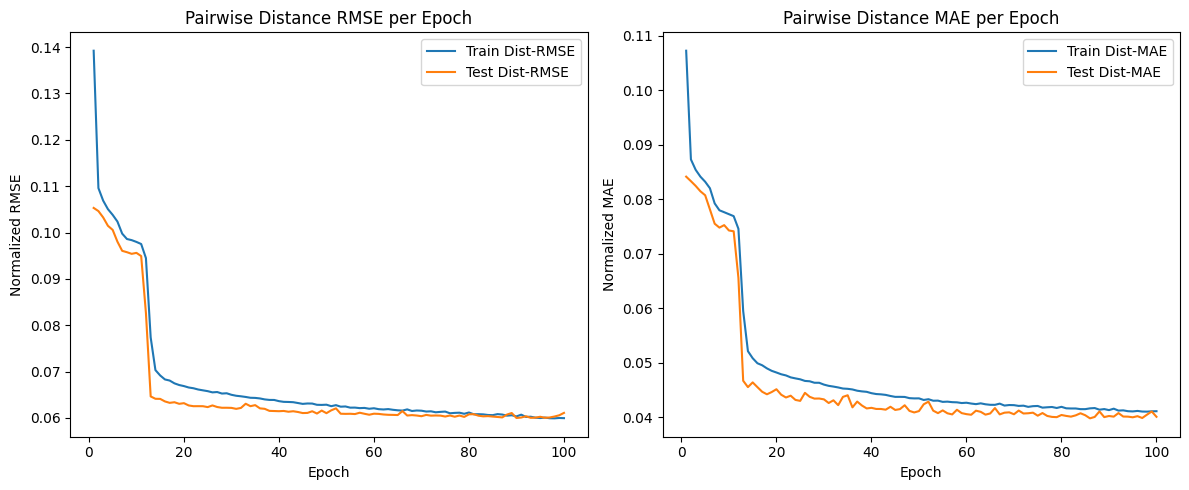

Test‐Window Distance RMSE: mean = 0.0574, std = 0.0209
Test‐Window Distance MAE: mean = 0.0401, std = 0.0140
Pearson correlation (true vs predicted distances): 0.8253


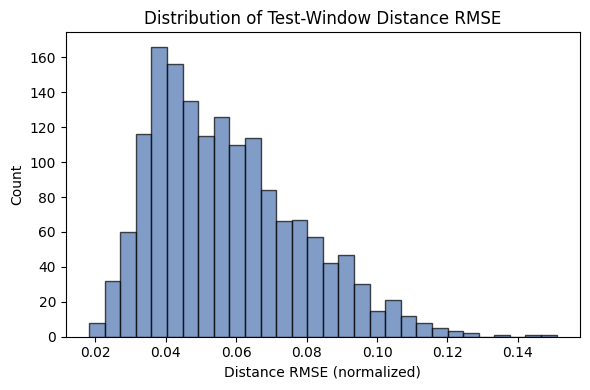

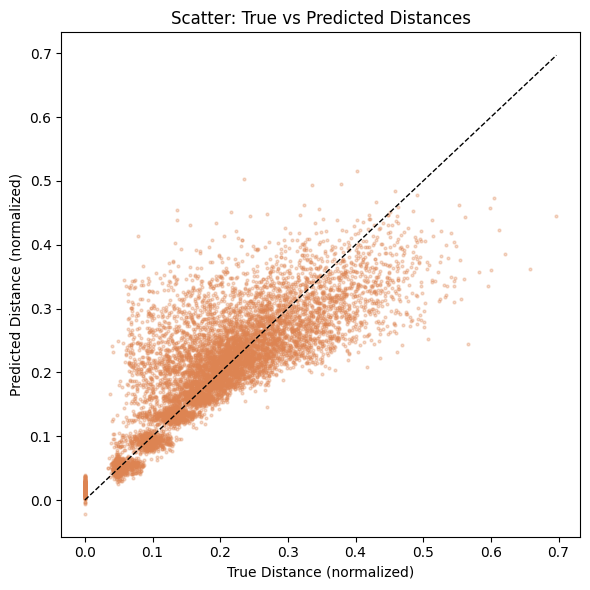

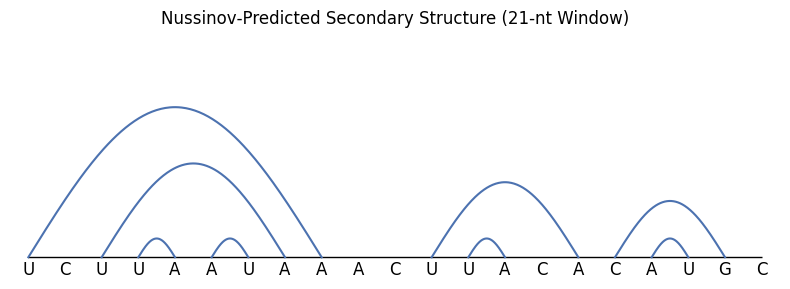

In [1]:
import os
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

# ──────────────────────────────────────────────────────────────────────────────
# 1) PATH SETUP (adjust if needed)
BASE_DIR = "/kaggle/input/stanford-rna-3d-folding/stanford-rna-3d-folding"

# 2) READ IN LABELS, SEQUENCES, AND MSA FILES
lbl_df = pd.read_csv(f"{BASE_DIR}/train_labels.v2.csv")
seqs_df = pd.read_excel(f"{BASE_DIR}/train_sequences.xlsx")
seq_map = {row["target_id"]: row["sequence"] for _, row in seqs_df.iterrows()}

# 3) FILTER for standard bases, attach sequence, and form base_id + resid
lbl_df = lbl_df[lbl_df["resname"].isin(["A", "C", "G", "U"])].copy()
lbl_df["base_id"] = lbl_df["ID"].apply(lambda x: "_".join(x.split("_")[:2]))
lbl_df["sequence"] = lbl_df["base_id"].map(seq_map)
lbl_df = lbl_df.dropna(subset=["sequence"]).reset_index(drop=True)

# 4) DEFINE HELPERS FOR MSA PROFILE & SEQUENCE WINDOW
from collections import Counter

def compute_profile_window(base_id: str, resid: int, window: int = 10):
    msa_path = f"{BASE_DIR}/MSA/{base_id}.MSA.fasta"
    if not os.path.isfile(msa_path):
        return None

    msa_seqs = []
    with open(msa_path, "r") as f:
        seq = None
        for line in f:
            line = line.strip()
            if line.startswith(">"):
                if seq is not None:
                    msa_seqs.append(seq)
                seq = ""
            else:
                seq += line
        if seq is not None:
            msa_seqs.append(seq)

    if len(msa_seqs) == 0:
        return None

    target_seq = msa_seqs[0]
    col_idx = None
    rcount = 0
    for i, ch in enumerate(target_seq):
        if ch != "-":
            rcount += 1
            if rcount == resid:
                col_idx = i
                break
    if col_idx is None:
        col_idx = len(target_seq) - 1

    profs = []
    L = len(target_seq)
    for offset in range(-window, window + 1):
        j = col_idx + offset
        if j < 0:
            j = 0
        elif j >= L:
            j = L - 1

        cnt = Counter(seq[j] for seq in msa_seqs)
        denom = float(sum(cnt[nuc] for nuc in ["A", "C", "G", "U"]))
        if denom == 0:
            profs.append([0.0, 0.0, 0.0, 0.0])
        else:
            profs.append([
                cnt["A"] / denom,
                cnt["C"] / denom,
                cnt["G"] / denom,
                cnt["U"] / denom
            ])
    return profs  # length = 2*window+1, each is [fA,fC,fG,fU]

def get_seq_window(seq: str, resid: int, window: int = 10):
    pos = resid - 1  # 0-based
    start = max(0, pos - window)
    end = min(len(seq), pos + window + 1)
    win = seq[start:end]
    need = (2 * window + 1) - len(win)
    if need > 0:
        if start == 0:
            win = "N" * need + win
        else:
            win = win + "N" * need
    return win

# 5) NORMALIZE ALL RAW COORDINATES, THEN BUILD coord_map
coords_raw = lbl_df[["x_1", "y_1", "z_1"]].values
scaler = StandardScaler()
coords_scaled_full = scaler.fit_transform(coords_raw)
lbl_df[["x", "y", "z"]] = coords_scaled_full

# Build a dictionary for retrieving normalized coords by (base_id, resid)
coord_map = {
    (row.base_id, int(row.resid)): (row.x, row.y, row.z)
    for _, row in lbl_df.iterrows()
}

# 6) FILTER OUT ANY ROWS WITH MISSING DATA OR NaNs
window = 10
valid_indices = []
for idx, row in lbl_df.iterrows():
    base_id = row.base_id
    resid = int(row.resid)
    seq = row.sequence

    # (a) Sequence window
    seq_win = get_seq_window(seq, resid, window)
    if len(seq_win) != 2 * window + 1:
        continue

    # (b) MSA profile
    prof_win = compute_profile_window(base_id, resid, window=window)
    if prof_win is None or len(prof_win) != 2 * window + 1:
        continue

    # (c) Check that every neighbor (base_id, resid + offset) exists in coord_map
    all_exist = True
    for offset in range(-window, window + 1):
        nb = resid + offset
        if (base_id, nb) not in coord_map:
            all_exist = False
            break
    if not all_exist:
        continue

    valid_indices.append(idx)

lbl_df = lbl_df.loc[valid_indices].reset_index(drop=True)

# 7) BUILD “features” (21×8) AND “true_coords” (21×3) FOR EACH ROW, ALSO DROP ANY NaNs
def encode_window_features(row):
    nuc_map_oh = {
        "A": [1, 0, 0, 0],
        "C": [0, 1, 0, 0],
        "G": [0, 0, 1, 0],
        "U": [0, 0, 0, 1],
        "N": [0, 0, 0, 0]
    }
    seq = row.sequence
    base_id = row.base_id
    resid = int(row.resid)

    seq_win = get_seq_window(seq, resid, window=window)
    prof_win = compute_profile_window(base_id, resid, window=window)
    if prof_win is None:
        return None

    features = []
    for i in range(2 * window + 1):
        onehot = nuc_map_oh.get(seq_win[i], [0, 0, 0, 0])
        prof = prof_win[i]
        features.append(onehot + prof)  # length 8
    return features  # list of length 21, each is 8 dims

def extract_true_coords_window(row):
    base_id = row.base_id
    resid = int(row.resid)
    coords21 = []
    for offset in range(-window, window + 1):
        nb = resid + offset
        coords21.append(coord_map[(base_id, nb)])  # (x',y',z')
    arr = np.array(coords21, dtype=np.float32)  # shape (21,3)
    if np.isnan(arr).any() or np.isinf(arr).any():
        return None
    return arr

lbl_df["features"] = lbl_df.apply(encode_window_features, axis=1)
lbl_df["true_coords"] = lbl_df.apply(extract_true_coords_window, axis=1)
lbl_df = lbl_df.dropna(subset=["features", "true_coords"]).reset_index(drop=True)

# 8) SAMPLE (up to 8000 rows) FOR SPEED; comment out to use all rows
lbl_df = lbl_df.sample(min(len(lbl_df), 8000), random_state=42).reset_index(drop=True)

# 9) DEFINE PyTorch DATASET FOR DISTANCE PREDICTION
class DistanceDataset(Dataset):
    def __init__(self, df):
        self.X = np.array(df["features"].tolist(), dtype=np.float32)        # (N,21,8)
        self.true_coords = np.array(df["true_coords"].tolist(), dtype=np.float32)  # (N,21,3)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        return (
            torch.tensor(self.X[i]),            # (21,8), float32
            torch.tensor(self.true_coords[i])   # (21,3), float32
        )

dataset = DistanceDataset(lbl_df)
train_n = int(0.8 * len(dataset))
train_set, test_set = random_split(dataset, [train_n, len(dataset) - train_n])
train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_set,  batch_size=64, shuffle=False)

# ──────────────────────────────────────────────────────────────────────────────
# 10) DEFINE “DistTransformer”: 21-nt Transformer → pairwise distance MLP
class DistTransformer(nn.Module):
    def __init__(self, window=10):
        super().__init__()
        self.window_len = 2 * window + 1  # 21
        self.feat_dim   = 8               # input feature dims
        self.d_model    = 64              # transformer embed dims
        self.nhead      = 8
        self.dim_feed   = 128
        self.nlayers    = 2
        self.dropout    = 0.1

        # (a) project 8→64
        self.input_proj = nn.Linear(self.feat_dim, self.d_model)

        # (b) learned positional embeddings for 21 positions
        self.pos_embed = nn.Parameter(torch.zeros(1, self.window_len, self.d_model))

        # (c) transformer encoder (2 layers, 8 heads)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=self.d_model,
            nhead=self.nhead,
            dim_feedforward=self.dim_feed,
            dropout=self.dropout,
            activation='relu',
            batch_first=True  # avoids nested‐tensor warning
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=self.nlayers)

        # (d) pairwise MLP head: concat E_i||E_j → 128 dims → scalar dist
        self.pair_mlp = nn.Sequential(
            nn.Linear(2 * self.d_model, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 1)
        )

        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward(self, x):
        """
        x: (batch_size, 21, 8)
        Returns: pred_dists: (batch_size, 21, 21)
        """
        B = x.size(0)

        # 1) project + add positional: (B,21,8) → (B,21,64)
        proj = self.input_proj(x) + self.pos_embed  # (B,21,64)

        # 2) transformer expects (B,21,64) with batch_first=True
        E = self.transformer(proj)  # → (B,21,64)

        # 3) pairwise concat: build (i,j) for all positions
        Ei = E.unsqueeze(2).expand(B, self.window_len, self.window_len, self.d_model)  # (B,21,21,64)
        Ej = E.unsqueeze(1).expand(B, self.window_len, self.window_len, self.d_model)  # (B,21,21,64)
        pair_feats = torch.cat([Ei, Ej], dim=-1)         # (B,21,21,128)

        # 4) flatten pairs → (B*21*21, 128) → MLP → (B*21*21,1)
        flat = pair_feats.reshape(-1, 2 * self.d_model)
        d_flat = self.pair_mlp(flat)                     # (B*21*21, 1)

        # 5) reshape → (B,21,21) & symmetrize
        dists = d_flat.view(B, self.window_len, self.window_len)
        dists_sym = 0.5 * (dists + dists.transpose(1, 2))
        return dists_sym

# 11) SET DEVICE, INSTANTIATE MODEL, OPTIMIZER, LOSS
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model     = DistTransformer(window=window).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-5)
loss_fn   = nn.MSELoss()

train_rmse, test_rmse = [], []
train_mae,  test_mae  = [], []

# 12) TRAINING LOOP: predict distance matrices
for epoch in range(1, 101):
    model.train()
    tr_preds, tr_tars = [], []

    for X_batch, true_coords in train_loader:
        X_batch = X_batch.to(device)                 # (B,21,8)
        true_coords = true_coords.to(device)         # (B,21,3)

        # (a) compute true pairwise distances: (B,21,21)
        true_dists = torch.cdist(true_coords, true_coords, p=2)

        # (b) forward → predicted distances
        pred_dists = model(X_batch)                  # (B,21,21)

        # (c) if any NaN in pred_dists or true_dists, skip this batch
        if torch.isnan(pred_dists).any() or torch.isnan(true_dists).any():
            continue

        loss = loss_fn(pred_dists, true_dists)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        tr_preds.append(pred_dists.detach().cpu().numpy())
        tr_tars.append(true_dists.detach().cpu().numpy())

    model.eval()
    te_preds, te_tars = [], []
    with torch.no_grad():
        for X_batch, true_coords in test_loader:
            X_batch = X_batch.to(device)
            true_coords = true_coords.to(device)
            true_dists = torch.cdist(true_coords, true_coords, p=2)
            pred_dists = model(X_batch)

            if torch.isnan(pred_dists).any() or torch.isnan(true_dists).any():
                continue

            te_preds.append(pred_dists.cpu().numpy())
            te_tars.append(true_dists.cpu().numpy())

    # If no valid batches in this epoch, record NaN and continue
    if len(tr_preds) == 0 or len(te_preds) == 0:
        print(f"Epoch {epoch:3d} | no valid (non-NaN) batches, skipping metrics")
        train_rmse.append(np.nan); test_rmse.append(np.nan)
        train_mae.append(np.nan);  test_mae.append(np.nan)
        continue

    tr_preds = np.vstack(tr_preds).reshape(-1, 21, 21)
    tr_tars = np.vstack(tr_tars).reshape(-1, 21, 21)
    te_preds = np.vstack(te_preds).reshape(-1, 21, 21)
    te_tars = np.vstack(te_tars).reshape(-1, 21, 21)

    rmse_tr = np.sqrt(np.mean((tr_preds - tr_tars) ** 2))
    rmse_te = np.sqrt(np.mean((te_preds - te_tars) ** 2))
    mae_tr  = np.mean(np.abs(tr_preds - tr_tars))
    mae_te  = np.mean(np.abs(te_preds - te_tars))

    train_rmse.append(rmse_tr); test_rmse.append(rmse_te)
    train_mae.append(mae_tr);  test_mae.append(mae_te)

    print(f"Epoch {epoch:3d} | Dist-RMSE = {rmse_tr:.4f}/{rmse_te:.4f} | "
          f"Dist-MAE = {mae_tr:.4f}/{mae_te:.4f}")

# ──────────────────────────────────────────────────────────────────────────────
# 13) PLOT TRAIN/TEST Distance-RMSE & Distance-MAE CURVES (lines only, no markers, no grids)
epochs = [e for e in range(1, len(train_rmse) + 1) if not np.isnan(train_rmse[e - 1])]
if len(epochs) > 0:
    valid_tr_rmse = [train_rmse[e - 1] for e in epochs]
    valid_te_rmse = [test_rmse[e - 1] for e in epochs]
    valid_tr_mae  = [train_mae[e - 1]  for e in epochs]
    valid_te_mae  = [test_mae[e - 1]   for e in epochs]

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, valid_tr_rmse, label="Train Dist-RMSE")
    plt.plot(epochs, valid_te_rmse, label="Test Dist-RMSE")
    plt.title("Pairwise Distance RMSE per Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Normalized RMSE")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, valid_tr_mae, label="Train Dist-MAE")
    plt.plot(epochs, valid_te_mae, label="Test Dist-MAE")
    plt.title("Pairwise Distance MAE per Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Normalized MAE")
    plt.legend()

    plt.tight_layout()
    plt.show()
else:
    print("All epochs were skipped (no valid batches). No loss curves to plot.")

# ──────────────────────────────────────────────────────────────────────────────
# 14) ADDITIONAL EVALUATION METRICS & PLOTS
# Compute per-window RMSE/MAE on test set, plus overall correlation of predicted vs true distances.

all_test_rmse = []
all_test_mae = []
all_true_flat = []
all_pred_flat = []

model.eval()
with torch.no_grad():
    for Xb, true_coords in test_loader:
        Xb = Xb.to(device)
        true_coords = true_coords.to(device)
        true_d = torch.cdist(true_coords, true_coords, p=2)         # (B,21,21)
        pred_d = model(Xb)                                          # (B,21,21)

        td_np = true_d.cpu().numpy()
        pd_np = pred_d.cpu().numpy()
        B = td_np.shape[0]

        for i in range(B):
            tmat = td_np[i]
            pmat = pd_np[i]
            mse = np.mean((tmat - pmat) ** 2)
            rmse = np.sqrt(mse)
            mae = np.mean(np.abs(tmat - pmat))
            all_test_rmse.append(rmse)
            all_test_mae.append(mae)
            all_true_flat.extend(tmat.flatten())
            all_pred_flat.extend(pmat.flatten())

all_test_rmse = np.array(all_test_rmse)
all_test_mae = np.array(all_test_mae)

# 14a) Print summary statistics
print(f"Test‐Window Distance RMSE: mean = {all_test_rmse.mean():.4f}, std = {all_test_rmse.std():.4f}")
print(f"Test‐Window Distance MAE: mean = {all_test_mae.mean():.4f}, std = {all_test_mae.std():.4f}")

# 14b) Compute Pearson correlation between true and predicted distances (flattened)
all_true_flat = np.array(all_true_flat)
all_pred_flat = np.array(all_pred_flat)
corr = np.corrcoef(all_true_flat, all_pred_flat)[0, 1]
print(f"Pearson correlation (true vs predicted distances): {corr:.4f}")

# 14c) Histogram of per-window RMSE
plt.figure(figsize=(6, 4))
plt.hist(all_test_rmse, bins=30, color="#4C72B0", edgecolor="black", alpha=0.7)
plt.title("Distribution of Test‐Window Distance RMSE")
plt.xlabel("Distance RMSE (normalized)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# 14d) Scatter plot of true vs predicted distances (sample up to 10k points for visibility)
idxs = np.random.choice(len(all_true_flat), size=min(10000, len(all_true_flat)), replace=False)
plt.figure(figsize=(6, 6))
plt.scatter(all_true_flat[idxs], all_pred_flat[idxs], s=4, alpha=0.3, color="#DD8452")
max_val = max(all_true_flat[idxs].max(), all_pred_flat[idxs].max())
plt.plot([0, max_val], [0, max_val], 'k--', linewidth=1)
plt.title("Scatter: True vs Predicted Distances")
plt.xlabel("True Distance (normalized)")
plt.ylabel("Predicted Distance (normalized)")
plt.tight_layout()
plt.show()

# ──────────────────────────────────────────────────────────────────────────────
# 15) OPTIONAL: Dot‐Bracket Secondary Structure Prediction (Nussinov)
# We'll pick the very first row of lbl_df, get its 21-nt window, run Nussinov DP,
# then plot an “arc diagram” showing base pairs.

def nussinov(seq):
    """
    Simple Nussinov algorithm for maximum base pairs (no wobble).
    Returns a dot-bracket string of length len(seq).
    """
    n = len(seq)
    dp = [[0] * n for _ in range(n)]
    bt = [[None] * n for _ in range(n)]

    def can_pair(a, b):
        return (a == "A" and b == "U") or (a == "U" and b == "A") or \
               (a == "C" and b == "G") or (a == "G" and b == "C")

    # Fill DP table
    for l in range(1, n):
        for i in range(n - l):
            j = i + l
            best = dp[i + 1][j]
            bt_choice = ("i+1,j", i + 1, j)
            if dp[i][j - 1] > best:
                best = dp[i][j - 1]
                bt_choice = ("i,j-1", i, j - 1)
            if can_pair(seq[i], seq[j]):
                val = 1 + (dp[i + 1][j - 1] if j - 1 >= i + 1 else 0)
                if val > best:
                    best = val
                    bt_choice = ("pair", i + 1, j - 1)
            for k in range(i + 1, j):
                val = dp[i][k] + dp[k + 1][j]
                if val > best:
                    best = val
                    bt_choice = ("bifur", i, k, k + 1, j)
            dp[i][j] = best
            bt[i][j] = bt_choice

    # Traceback
    pairs = set()
    def trace(i, j):
        if i >= j:
            return
        choice = bt[i][j]
        if choice is None:
            return
        if choice[0] == "i+1,j":
            trace(choice[1], choice[2])
        elif choice[0] == "i,j-1":
            trace(choice[1], choice[2])
        elif choice[0] == "pair":
            pairs.add((i, j))
            trace(choice[1], choice[2])
        elif choice[0] == "bifur":
            _, i1, k1, i2, j2 = choice
            trace(i1, k1)
            trace(i2, j2)

    trace(0, n - 1)

    # Build dot-bracket
    db = ["." for _ in range(n)]
    for i, j in pairs:
        db[i] = "("
        db[j] = ")"
    return "".join(db), pairs

# Get the very first example's 21-nt window
first_row = lbl_df.iloc[0]
seq21 = get_seq_window(first_row["sequence"], int(first_row["resid"]), window)
db_string, db_pairs = nussinov(seq21)

# Plot arc diagram
plt.figure(figsize=(8, 3))
x = np.arange(len(seq21))
# Plot baseline
plt.hlines(0, 0, len(seq21) - 1, color="black", linewidth=1)

# Annotate sequence letters
for i, nt in enumerate(seq21):
    plt.text(i, -0.1, nt, ha="center", va="top", fontsize=12)

# Draw arcs for each base pair
for (i, j) in db_pairs:
    xs = np.linspace(i, j, 200)
    heights = (j - i) / 2 * np.sin(np.pi * (xs - i) / (j - i))
    plt.plot(xs, heights, color="#4C72B0")

plt.title("Nussinov‐Predicted Secondary Structure (21-nt Window)")
plt.ylim(-0.5, window * 0.6)  # leave space for arcs
plt.xlim(-0.5, len(seq21) - 0.5)
plt.axis("off")
plt.tight_layout()
plt.show()


Epoch   1 | Dist-RMSE = 0.1409/0.1054 | Dist-MAE = 0.1089/0.0847
Epoch  50 | Dist-RMSE = 0.0630/0.0609 | Dist-MAE = 0.0435/0.0403
Epoch 100 | Dist-RMSE = 0.0597/0.0596 | Dist-MAE = 0.0410/0.0397
Epoch 150 | Dist-RMSE = 0.0565/0.0596 | Dist-MAE = 0.0390/0.0390
Epoch 200 | Dist-RMSE = 0.0540/0.0595 | Dist-MAE = 0.0376/0.0392
Epoch 250 | Dist-RMSE = 0.0522/0.0609 | Dist-MAE = 0.0365/0.0393
Epoch 300 | Dist-RMSE = 0.0507/0.0606 | Dist-MAE = 0.0357/0.0391
Epoch 350 | Dist-RMSE = 0.0494/0.0607 | Dist-MAE = 0.0349/0.0393
Epoch 400 | Dist-RMSE = 0.0484/0.0611 | Dist-MAE = 0.0343/0.0394
Epoch 450 | Dist-RMSE = 0.0474/0.0616 | Dist-MAE = 0.0337/0.0395
Epoch 500 | Dist-RMSE = 0.0469/0.0612 | Dist-MAE = 0.0335/0.0394


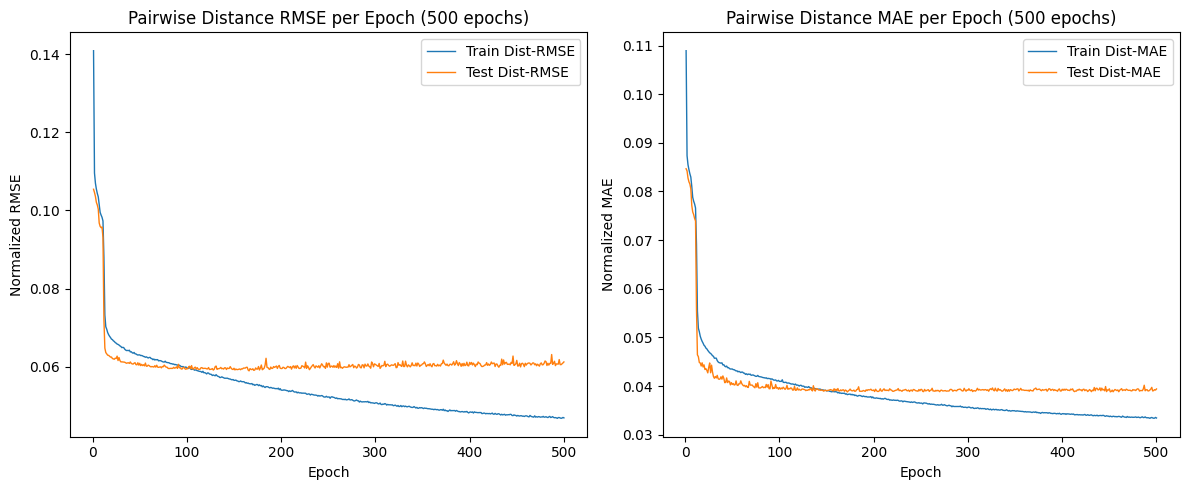

Test‐Window Distance RMSE: mean = 0.0569, std = 0.0225
Test‐Window Distance MAE: mean = 0.0394, std = 0.0145
Pearson correlation (true vs predicted distances): 0.8248


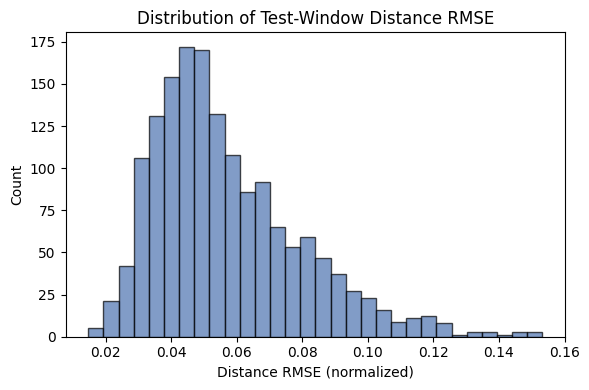

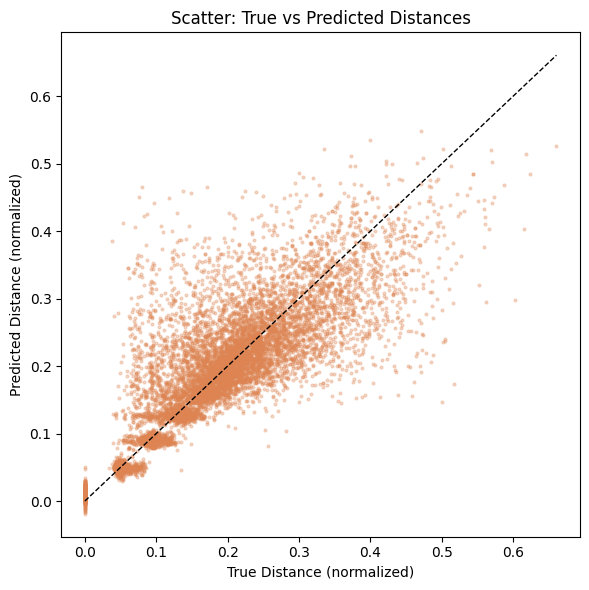

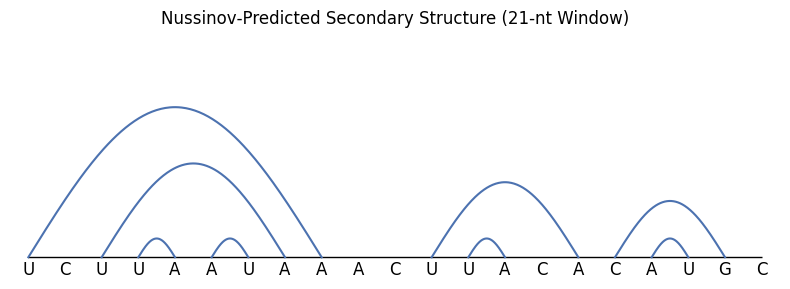

In [1]:
import os
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

# ──────────────────────────────────────────────────────────────────────────────
# 1) PATH SETUP (adjust if needed)
BASE_DIR = "/kaggle/input/stanford-rna-3d-folding/stanford-rna-3d-folding"

# 2) READ IN LABELS, SEQUENCES, AND MSA FILES
lbl_df = pd.read_csv(f"{BASE_DIR}/train_labels.v2.csv")
seqs_df = pd.read_excel(f"{BASE_DIR}/train_sequences.xlsx")
seq_map = {row["target_id"]: row["sequence"] for _, row in seqs_df.iterrows()}

# 3) FILTER for standard bases, attach sequence, and form base_id + resid
lbl_df = lbl_df[lbl_df["resname"].isin(["A", "C", "G", "U"])].copy()
lbl_df["base_id"] = lbl_df["ID"].apply(lambda x: "_".join(x.split("_")[:2]))
lbl_df["sequence"] = lbl_df["base_id"].map(seq_map)
lbl_df = lbl_df.dropna(subset=["sequence"]).reset_index(drop=True)

# 4) DEFINE HELPERS FOR MSA PROFILE & SEQUENCE WINDOW
from collections import Counter

def compute_profile_window(base_id: str, resid: int, window: int = 10):
    msa_path = f"{BASE_DIR}/MSA/{base_id}.MSA.fasta"
    if not os.path.isfile(msa_path):
        return None

    msa_seqs = []
    with open(msa_path, "r") as f:
        seq = None
        for line in f:
            line = line.strip()
            if line.startswith(">"):
                if seq is not None:
                    msa_seqs.append(seq)
                seq = ""
            else:
                seq += line
        if seq is not None:
            msa_seqs.append(seq)

    if len(msa_seqs) == 0:
        return None

    target_seq = msa_seqs[0]
    col_idx = None
    rcount = 0
    for i, ch in enumerate(target_seq):
        if ch != "-":
            rcount += 1
            if rcount == resid:
                col_idx = i
                break
    if col_idx is None:
        col_idx = len(target_seq) - 1

    profs = []
    L = len(target_seq)
    for offset in range(-window, window + 1):
        j = col_idx + offset
        if j < 0:
            j = 0
        elif j >= L:
            j = L - 1

        cnt = Counter(seq[j] for seq in msa_seqs)
        denom = float(sum(cnt[nuc] for nuc in ["A", "C", "G", "U"]))
        if denom == 0:
            profs.append([0.0, 0.0, 0.0, 0.0])
        else:
            profs.append([
                cnt["A"] / denom,
                cnt["C"] / denom,
                cnt["G"] / denom,
                cnt["U"] / denom
            ])
    return profs  # length = 2*window+1, each is [fA,fC,fG,fU]

def get_seq_window(seq: str, resid: int, window: int = 10):
    pos = resid - 1  # 0-based
    start = max(0, pos - window)
    end = min(len(seq), pos + window + 1)
    win = seq[start:end]
    need = (2 * window + 1) - len(win)
    if need > 0:
        if start == 0:
            win = "N" * need + win
        else:
            win = win + "N" * need
    return win

# 5) NORMALIZE ALL RAW COORDINATES, THEN BUILD coord_map
coords_raw = lbl_df[["x_1", "y_1", "z_1"]].values
scaler = StandardScaler()
coords_scaled_full = scaler.fit_transform(coords_raw)
lbl_df[["x", "y", "z"]] = coords_scaled_full

# Build a dictionary for retrieving normalized coords by (base_id, resid)
coord_map = {
    (row.base_id, int(row.resid)): (row.x, row.y, row.z)
    for _, row in lbl_df.iterrows()
}

# 6) FILTER OUT ANY ROWS WITH MISSING DATA OR NaNs
window = 10
valid_indices = []
for idx, row in lbl_df.iterrows():
    base_id = row.base_id
    resid = int(row.resid)
    seq = row.sequence

    # (a) Sequence window
    seq_win = get_seq_window(seq, resid, window)
    if len(seq_win) != 2 * window + 1:
        continue

    # (b) MSA profile
    prof_win = compute_profile_window(base_id, resid, window=window)
    if prof_win is None or len(prof_win) != 2 * window + 1:
        continue

    # (c) Check that every neighbor (base_id, resid + offset) exists in coord_map
    all_exist = True
    for offset in range(-window, window + 1):
        nb = resid + offset
        if (base_id, nb) not in coord_map:
            all_exist = False
            break
    if not all_exist:
        continue

    valid_indices.append(idx)

lbl_df = lbl_df.loc[valid_indices].reset_index(drop=True)

# 7) BUILD “features” (21×8) AND “true_coords” (21×3) FOR EACH ROW, ALSO DROP ANY NaNs
def encode_window_features(row):
    nuc_map_oh = {
        "A": [1, 0, 0, 0],
        "C": [0, 1, 0, 0],
        "G": [0, 0, 1, 0],
        "U": [0, 0, 0, 1],
        "N": [0, 0, 0, 0]
    }
    seq = row.sequence
    base_id = row.base_id
    resid = int(row.resid)

    seq_win = get_seq_window(seq, resid, window=window)
    prof_win = compute_profile_window(base_id, resid, window=window)
    if prof_win is None:
        return None

    features = []
    for i in range(2 * window + 1):
        onehot = nuc_map_oh.get(seq_win[i], [0, 0, 0, 0])
        prof = prof_win[i]
        features.append(onehot + prof)  # length 8
    return features  # list of length 21, each is 8 dims

def extract_true_coords_window(row):
    base_id = row.base_id
    resid = int(row.resid)
    coords21 = []
    for offset in range(-window, window + 1):
        nb = resid + offset
        coords21.append(coord_map[(base_id, nb)])  # (x',y',z')
    arr = np.array(coords21, dtype=np.float32)  # shape (21,3)
    if np.isnan(arr).any() or np.isinf(arr).any():
        return None
    return arr

lbl_df["features"] = lbl_df.apply(encode_window_features, axis=1)
lbl_df["true_coords"] = lbl_df.apply(extract_true_coords_window, axis=1)
lbl_df = lbl_df.dropna(subset=["features", "true_coords"]).reset_index(drop=True)

# 8) SAMPLE (up to 8000 rows) FOR SPEED; comment out to use all rows
lbl_df = lbl_df.sample(min(len(lbl_df), 8000), random_state=42).reset_index(drop=True)

# 9) DEFINE PyTorch DATASET FOR DISTANCE PREDICTION
class DistanceDataset(Dataset):
    def __init__(self, df):
        self.X = np.array(df["features"].tolist(), dtype=np.float32)        # (N,21,8)
        self.true_coords = np.array(df["true_coords"].tolist(), dtype=np.float32)  # (N,21,3)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        return (
            torch.tensor(self.X[i]),            # (21,8), float32
            torch.tensor(self.true_coords[i])   # (21,3), float32
        )

dataset = DistanceDataset(lbl_df)
train_n = int(0.8 * len(dataset))
train_set, test_set = random_split(dataset, [train_n, len(dataset) - train_n])
train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_set,  batch_size=64, shuffle=False)

# ──────────────────────────────────────────────────────────────────────────────
# 10) DEFINE “DistTransformer”: 21-nt Transformer → pairwise distance MLP
class DistTransformer(nn.Module):
    def __init__(self, window=10):
        super().__init__()
        self.window_len = 2 * window + 1  # 21
        self.feat_dim   = 8               # input feature dims
        self.d_model    = 64              # transformer embed dims
        self.nhead      = 8
        self.dim_feed   = 128
        self.nlayers    = 2
        self.dropout    = 0.1

        # (a) project 8→64
        self.input_proj = nn.Linear(self.feat_dim, self.d_model)

        # (b) learned positional embeddings for 21 positions
        self.pos_embed = nn.Parameter(torch.zeros(1, self.window_len, self.d_model))

        # (c) transformer encoder (2 layers, 8 heads)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=self.d_model,
            nhead=self.nhead,
            dim_feedforward=self.dim_feed,
            dropout=self.dropout,
            activation='relu',
            batch_first=True  # avoids nested‐tensor warning
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=self.nlayers)

        # (d) pairwise MLP head: concat E_i||E_j → 128 dims → scalar dist
        self.pair_mlp = nn.Sequential(
            nn.Linear(2 * self.d_model, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 1)
        )

        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward(self, x):
        """
        x: (batch_size, 21, 8)
        Returns: pred_dists: (batch_size, 21, 21)
        """
        B = x.size(0)

        # 1) project + add positional: (B,21,8) → (B,21,64)
        proj = self.input_proj(x) + self.pos_embed  # (B,21,64)

        # 2) transformer expects (B,21,64) with batch_first=True
        E = self.transformer(proj)  # → (B,21,64)

        # 3) pairwise concat: build (i,j) for all positions
        Ei = E.unsqueeze(2).expand(B, self.window_len, self.window_len, self.d_model)  # (B,21,21,64)
        Ej = E.unsqueeze(1).expand(B, self.window_len, self.window_len, self.d_model)  # (B,21,21,64)
        pair_feats = torch.cat([Ei, Ej], dim=-1)         # (B,21,21,128)

        # 4) flatten pairs → (B*21*21, 128) → MLP → (B*21*21,1)
        flat = pair_feats.reshape(-1, 2 * self.d_model)
        d_flat = self.pair_mlp(flat)                     # (B*21*21, 1)

        # 5) reshape → (B,21,21) & symmetrize
        dists = d_flat.view(B, self.window_len, self.window_len)
        dists_sym = 0.5 * (dists + dists.transpose(1, 2))
        return dists_sym

# 11) SET DEVICE, INSTANTIATE MODEL, OPTIMIZER, LOSS
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model     = DistTransformer(window=window).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-5)
loss_fn   = nn.MSELoss()

train_rmse, test_rmse = [], []
train_mae,  test_mae  = [], []

# 12) TRAINING LOOP: predict distance matrices for 500 epochs
num_epochs = 500
for epoch in range(1, num_epochs + 1):
    model.train()
    tr_preds, tr_tars = [], []

    for X_batch, true_coords in train_loader:
        X_batch = X_batch.to(device)                 # (B,21,8)
        true_coords = true_coords.to(device)         # (B,21,3)

        # (a) compute true pairwise distances: (B,21,21)
        true_dists = torch.cdist(true_coords, true_coords, p=2)

        # (b) forward → predicted distances
        pred_dists = model(X_batch)                  # (B,21,21)

        # (c) if any NaN in pred_dists or true_dists, skip this batch
        if torch.isnan(pred_dists).any() or torch.isnan(true_dists).any():
            continue

        loss = loss_fn(pred_dists, true_dists)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        tr_preds.append(pred_dists.detach().cpu().numpy())
        tr_tars.append(true_dists.detach().cpu().numpy())

    model.eval()
    te_preds, te_tars = [], []
    with torch.no_grad():
        for X_batch, true_coords in test_loader:
            X_batch = X_batch.to(device)
            true_coords = true_coords.to(device)
            true_dists = torch.cdist(true_coords, true_coords, p=2)
            pred_dists = model(X_batch)

            if torch.isnan(pred_dists).any() or torch.isnan(true_dists).any():
                continue

            te_preds.append(pred_dists.cpu().numpy())
            te_tars.append(true_dists.cpu().numpy())

    # If no valid batches in this epoch, record NaN and continue
    if len(tr_preds) == 0 or len(te_preds) == 0:
        print(f"Epoch {epoch:3d} | no valid (non-NaN) batches, skipping metrics")
        train_rmse.append(np.nan); test_rmse.append(np.nan)
        train_mae.append(np.nan);  test_mae.append(np.nan)
        continue

    tr_preds = np.vstack(tr_preds).reshape(-1, 21, 21)
    tr_tars = np.vstack(tr_tars).reshape(-1, 21, 21)
    te_preds = np.vstack(te_preds).reshape(-1, 21, 21)
    te_tars = np.vstack(te_tars).reshape(-1, 21, 21)

    rmse_tr = np.sqrt(np.mean((tr_preds - tr_tars) ** 2))
    rmse_te = np.sqrt(np.mean((te_preds - te_tars) ** 2))
    mae_tr  = np.mean(np.abs(tr_preds - tr_tars))
    mae_te  = np.mean(np.abs(te_preds - te_tars))

    train_rmse.append(rmse_tr); test_rmse.append(rmse_te)
    train_mae.append(mae_tr);  test_mae.append(mae_te)

    if epoch % 50 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d} | Dist-RMSE = {rmse_tr:.4f}/{rmse_te:.4f} | Dist-MAE = {mae_tr:.4f}/{mae_te:.4f}")

# ──────────────────────────────────────────────────────────────────────────────
# 13) PLOT TRAIN/TEST Distance-RMSE & Distance-MAE CURVES (lines only, no markers, no grids)
epochs = [e for e in range(1, len(train_rmse) + 1) if not np.isnan(train_rmse[e - 1])]
if len(epochs) > 0:
    valid_tr_rmse = [train_rmse[e - 1] for e in epochs]
    valid_te_rmse = [test_rmse[e - 1] for e in epochs]
    valid_tr_mae  = [train_mae[e - 1]  for e in epochs]
    valid_te_mae  = [test_mae[e - 1]   for e in epochs]

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, valid_tr_rmse, label="Train Dist-RMSE", linewidth=1)
    plt.plot(epochs, valid_te_rmse, label="Test Dist-RMSE", linewidth=1)
    plt.title("Pairwise Distance RMSE per Epoch (500 epochs)")
    plt.xlabel("Epoch")
    plt.ylabel("Normalized RMSE")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, valid_tr_mae, label="Train Dist-MAE", linewidth=1)
    plt.plot(epochs, valid_te_mae, label="Test Dist-MAE", linewidth=1)
    plt.title("Pairwise Distance MAE per Epoch (500 epochs)")
    plt.xlabel("Epoch")
    plt.ylabel("Normalized MAE")
    plt.legend()

    plt.tight_layout()
    plt.show()
else:
    print("All epochs were skipped (no valid batches). No loss curves to plot.")

# ──────────────────────────────────────────────────────────────────────────────
# 14) ADDITIONAL EVALUATION METRICS & PLOTS
# Compute per-window RMSE/MAE on test set, plus overall correlation of predicted vs true distances.

all_test_rmse = []
all_test_mae = []
all_true_flat = []
all_pred_flat = []

model.eval()
with torch.no_grad():
    for Xb, true_coords in test_loader:
        Xb = Xb.to(device)
        true_coords = true_coords.to(device)
        true_d = torch.cdist(true_coords, true_coords, p=2)         # (B,21,21)
        pred_d = model(Xb)                                          # (B,21,21)

        td_np = true_d.cpu().numpy()
        pd_np = pred_d.cpu().numpy()
        B = td_np.shape[0]

        for i in range(B):
            tmat = td_np[i]
            pmat = pd_np[i]
            mse = np.mean((tmat - pmat) ** 2)
            rmse = np.sqrt(mse)
            mae = np.mean(np.abs(tmat - pmat))
            all_test_rmse.append(rmse)
            all_test_mae.append(mae)
            all_true_flat.extend(tmat.flatten())
            all_pred_flat.extend(pmat.flatten())

all_test_rmse = np.array(all_test_rmse)
all_test_mae = np.array(all_test_mae)

# 14a) Print summary statistics
print(f"Test‐Window Distance RMSE: mean = {all_test_rmse.mean():.4f}, std = {all_test_rmse.std():.4f}")
print(f"Test‐Window Distance MAE: mean = {all_test_mae.mean():.4f}, std = {all_test_mae.std():.4f}")

# 14b) Compute Pearson correlation between true and predicted distances (flattened)
all_true_flat = np.array(all_true_flat)
all_pred_flat = np.array(all_pred_flat)
corr = np.corrcoef(all_true_flat, all_pred_flat)[0, 1]
print(f"Pearson correlation (true vs predicted distances): {corr:.4f}")

# 14c) Histogram of per-window RMSE
plt.figure(figsize=(6, 4))
plt.hist(all_test_rmse, bins=30, color="#4C72B0", edgecolor="black", alpha=0.7)
plt.title("Distribution of Test‐Window Distance RMSE")
plt.xlabel("Distance RMSE (normalized)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# 14d) Scatter plot of true vs predicted distances (sample up to 10k points for visibility)
idxs = np.random.choice(len(all_true_flat), size=min(10000, len(all_true_flat)), replace=False)
plt.figure(figsize=(6, 6))
plt.scatter(all_true_flat[idxs], all_pred_flat[idxs], s=4, alpha=0.3, color="#DD8452")
max_val = max(all_true_flat[idxs].max(), all_pred_flat[idxs].max())
plt.plot([0, max_val], [0, max_val], 'k--', linewidth=1)
plt.title("Scatter: True vs Predicted Distances")
plt.xlabel("True Distance (normalized)")
plt.ylabel("Predicted Distance (normalized)")
plt.tight_layout()
plt.show()

# ──────────────────────────────────────────────────────────────────────────────
# 15) OPTIONAL: Dot‐Bracket Secondary Structure Prediction (Nussinov)
# We'll pick the very first row of lbl_df, get its 21-nt window, run Nussinov DP,
# then plot an “arc diagram” showing base pairs.

def nussinov(seq):
    """
    Simple Nussinov algorithm for maximum base pairs (no wobble).
    Returns a dot-bracket string of length len(seq).
    """
    n = len(seq)
    dp = [[0] * n for _ in range(n)]
    bt = [[None] * n for _ in range(n)]

    def can_pair(a, b):
        return (a == "A" and b == "U") or (a == "U" and b == "A") or \
               (a == "C" and b == "G") or (a == "G" and b == "C")

    # Fill DP table
    for l in range(1, n):
        for i in range(n - l):
            j = i + l
            best = dp[i + 1][j]
            bt_choice = ("i+1,j", i + 1, j)
            if dp[i][j - 1] > best:
                best = dp[i][j - 1]
                bt_choice = ("i,j-1", i, j - 1)
            if can_pair(seq[i], seq[j]):
                val = 1 + (dp[i + 1][j - 1] if j - 1 >= i + 1 else 0)
                if val > best:
                    best = val
                    bt_choice = ("pair", i + 1, j - 1)
            for k in range(i + 1, j):
                val = dp[i][k] + dp[k + 1][j]
                if val > best:
                    best = val
                    bt_choice = ("bifur", i, k, k + 1, j)
            dp[i][j] = best
            bt[i][j] = bt_choice

    # Traceback
    pairs = set()
    def trace(i, j):
        if i >= j:
            return
        choice = bt[i][j]
        if choice is None:
            return
        if choice[0] == "i+1,j":
            trace(choice[1], choice[2])
        elif choice[0] == "i,j-1":
            trace(choice[1], choice[2])
        elif choice[0] == "pair":
            pairs.add((i, j))
            trace(choice[1], choice[2])
        elif choice[0] == "bifur":
            _, i1, k1, i2, j2 = choice
            trace(i1, k1)
            trace(i2, j2)

    trace(0, n - 1)

    # Build dot-bracket
    db = ["." for _ in range(n)]
    for i, j in pairs:
        db[i] = "("
        db[j] = ")"
    return "".join(db), pairs

# Get the very first example's 21-nt window
first_row = lbl_df.iloc[0]
seq21 = get_seq_window(first_row["sequence"], int(first_row["resid"]), window)
db_string, db_pairs = nussinov(seq21)

# Plot arc diagram
plt.figure(figsize=(8, 3))
x = np.arange(len(seq21))
# Plot baseline
plt.hlines(0, 0, len(seq21) - 1, color="black", linewidth=1)

# Annotate sequence letters
for i, nt in enumerate(seq21):
    plt.text(i, -0.1, nt, ha="center", va="top", fontsize=12)

# Draw arcs for each base pair
for (i, j) in db_pairs:
    xs = np.linspace(i, j, 200)
    heights = (j - i) / 2 * np.sin(np.pi * (xs - i) / (j - i))
    plt.plot(xs, heights, color="#4C72B0")

plt.title("Nussinov‐Predicted Secondary Structure (21-nt Window)")
plt.ylim(-0.5, window * 0.6)  # leave space for arcs
plt.xlim(-0.5, len(seq21) - 0.5)
plt.axis("off")
plt.tight_layout()
plt.show()
